# Figura 10 — Comparação HTTP vs WebSocket (envio e recebimento)

Reproduz o gráfico equivalente à **Figura 10** do artigo *Comparison of WebSocket and HTTP Protocol Performance* (Łasocha & Badurowicz, 2021): tempo médio de transferência combinando **4 séries** — envio HTTP, recebimento HTTP, envio WebSocket e recebimento WebSocket — por quantidade de cópias.

**Diferença em relação ao artigo original**: no artigo, a Figura 10 é feita apenas com o laptop Acer Aspire 5 (o mais rápido), e a Figura 11 repete a mesma comparação com o Asus K50IN (o mais lento) — os navegadores são combinados por média. Aqui, como só existe um perfil de hardware (containers Docker na mesma máquina), este notebook produz a comparação única equivalente — não há uma "Figura 11" separada para replicar, pois não há um segundo hardware para comparar.

## Configuração e carga dos dados

Este notebook espera estar em `results/notebook/` dentro do projeto, e busca os CSVs em `results/csv/` (dois níveis acima, depois entrando em `csv/`).

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# notebook está em results/notebook/ -> sobe 2 níveis (results/notebook -> results -> raiz)
# e entra em results/csv
CSV_DIR = Path.cwd().parents[1] / "results" / "csv"

FILES = {
    "HTTP - envio": CSV_DIR / "http-send-oh0.csv",
    "HTTP - recebimento": CSV_DIR / "http-receive-oh0.csv",
    "WebSocket - envio": CSV_DIR / "ws-send-oh0.csv",
    "WebSocket - recebimento": CSV_DIR / "ws-receive-oh0.csv",
}

print(f"Diretório de CSVs: {CSV_DIR.resolve()}")
print(f"Existe? {CSV_DIR.exists()}\n")
for label, path in FILES.items():
    print(f" - {label:28s} ({path.name}): {'encontrado' if path.exists() else 'NÃO encontrado'}")

Diretório de CSVs: /home/ryan-correia/Área de trabalho/.projetos/repositorios/github/ComputerNetworksManagement/ifpb/converged_networks/advanced_project/results/csv
Existe? True

 - HTTP - envio                 (http-send-oh0.csv): encontrado
 - HTTP - recebimento           (http-receive-oh0.csv): encontrado
 - WebSocket - envio            (ws-send-oh0.csv): encontrado
 - WebSocket - recebimento      (ws-receive-oh0.csv): encontrado


In [18]:
dfs = {label: pd.read_csv(path) for label, path in FILES.items()}

# Formato esperado em cada arquivo: colunas [copies, run, time_ms]
for label, df in dfs.items():
    print(f"--- {label} ---")
    display(df.head(3))

--- HTTP - envio ---


,copies,run,time_ms
0,1,1,3.153
1,1,2,1.364
2,1,3,1.225


--- HTTP - recebimento ---


,copies,run,time_ms
0,1,1,2.193
1,1,2,2.086
2,1,3,1.600


--- WebSocket - envio ---


,copies,run,time_ms
0,1,1,0.922
1,1,2,0.365
2,1,3,0.338


--- WebSocket - recebimento ---


,copies,run,time_ms
0,1,1,0.772
1,1,2,0.440
2,1,3,0.278


## Checagem de integridade dos dados

O artigo mede as cópias **1, 3, 10, 30, 100, 300, 1000, 3000**, com **10 repetições** (`run`) cada, para todas as 4 séries. A célula abaixo avisa se algum dos 4 arquivos estiver com pontos faltando ou repetições insuficientes — importante aqui porque este notebook depende dos 4 arquivos estarem consistentes entre si (mesmas quantidades de cópias) para o agrupamento funcionar corretamente.

In [19]:
EXPECTED_COPIES = [1, 3, 10, 30, 100, 300, 1000, 3000]
EXPECTED_RUNS = 10

def check_integrity(df, label):
    print(f"--- {label} ---")
    counts = df.groupby("copies")["run"].count()
    missing = [c for c in EXPECTED_COPIES if c not in counts.index]
    extra = [c for c in counts.index if c not in EXPECTED_COPIES]
    ok = True
    if missing:
        print(f"Faltando quantidades de cópias: {missing}")
        ok = False
    if extra:
        print(f"Quantidades de cópias inesperadas presentes: {extra}")
        ok = False
    under_run = counts[counts < EXPECTED_RUNS]
    if not under_run.empty:
        print(f"Menos de {EXPECTED_RUNS} repetições para:\n{under_run}")
        ok = False
    if ok:
        print("Todos os pontos esperados presentes, com o número correto de repetições.")
    print()
    return ok

all_ok = True
for label, df in dfs.items():
    all_ok = check_integrity(df, label) and all_ok

if not all_ok:
    print("ATENÇÃO: pelo menos um arquivo está incompleto ou inconsistente. "
          "O gráfico combinado abaixo pode ficar incompleto ou distorcido até isso ser corrigido.")

--- HTTP - envio ---
Todos os pontos esperados presentes, com o número correto de repetições.

--- HTTP - recebimento ---
Todos os pontos esperados presentes, com o número correto de repetições.

--- WebSocket - envio ---
Todos os pontos esperados presentes, com o número correto de repetições.

--- WebSocket - recebimento ---
Todos os pontos esperados presentes, com o número correto de repetições.



## Cálculo das médias por quantidade de cópias

Igual à metodologia do artigo (seção 4.1): cada ponto é a média das 10 repetições, para cada uma das 4 séries.

In [20]:
def summarize(df):
    g = df.groupby("copies")["time_ms"].mean()
    return g.reindex([c for c in EXPECTED_COPIES if c in g.index])

means = pd.DataFrame({label: summarize(df) for label, df in dfs.items()})
means

,HTTP - envio,HTTP - recebimento,WebSocket - envio,WebSocket - recebimento
copies,,,,
1,1.7285,1.3349,0.6745,0.3247
3,4.5368,3.0672,1.2520,0.5051
10,10.8441,9.7446,4.2079,1.3352
30,31.8521,22.4698,9.6386,4.9003
100,91.3757,71.8444,27.4378,16.0369
300,161.7060,153.2832,39.7053,30.9895
1000,559.3122,430.0165,91.4081,70.3323
3000,1494.3469,1279.2073,205.8947,254.7156


## Figura 10 — Comparação HTTP vs WebSocket (envio e recebimento)

Gráfico de barras agrupadas: para cada quantidade de cópias, 4 barras lado a lado (HTTP-envio, HTTP-recebimento, WS-envio, WS-recebimento).

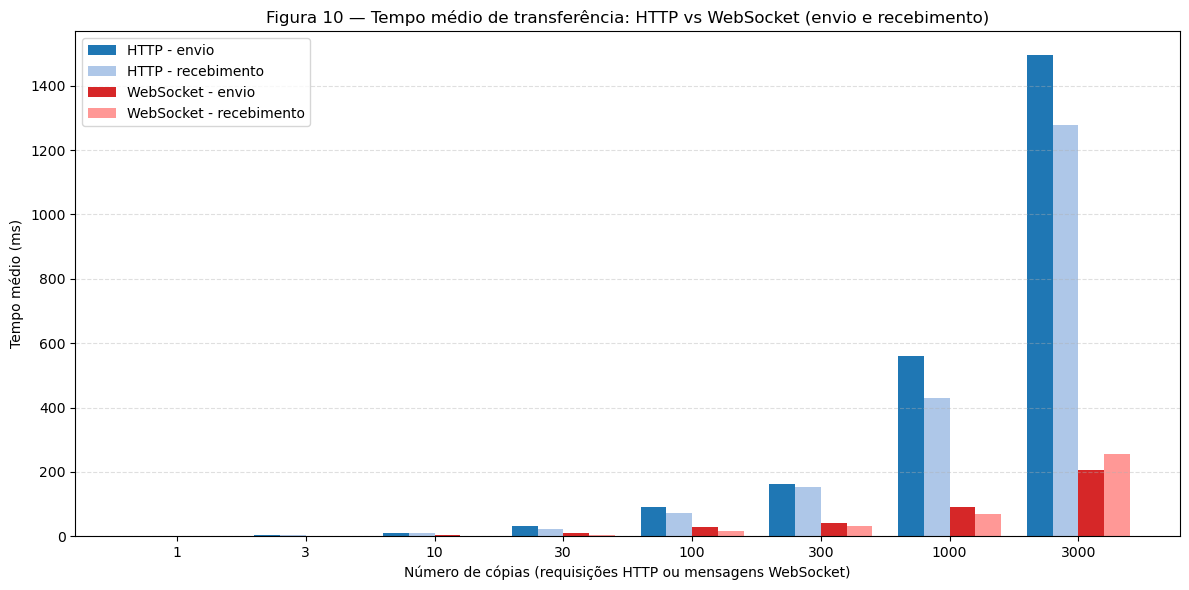

In [21]:
COLORS = {
    "HTTP - envio": "#1f77b4",
    "HTTP - recebimento": "#aec7e8",
    "WebSocket - envio": "#d62728",
    "WebSocket - recebimento": "#ff9896",
}

def plot_grouped_bars(means_df, title, ylabel="Tempo médio (ms)"):
    labels = [str(c) for c in means_df.index]
    n_series = len(means_df.columns)
    x = np.arange(len(labels))
    width = 0.8 / n_series

    fig, ax = plt.subplots(figsize=(12, 6))
    for i, col in enumerate(means_df.columns):
        offset = (i - (n_series - 1) / 2) * width
        ax.bar(x + offset, means_df[col], width, label=col, color=COLORS.get(col))

    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_title(title)
    ax.set_xlabel("Número de cópias (requisições HTTP ou mensagens WebSocket)")
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.legend()
    fig.tight_layout()
    return fig, ax

plot_grouped_bars(
    means,
    "Figura 10 — Tempo médio de transferência: HTTP vs WebSocket (envio e recebimento)",
)
plt.show()

## Versão em escala logarítmica

Como os valores variam de frações de milissegundo (1 cópia) a centenas de milissegundos (3000 cópias), uma escala logarítmica no eixo Y facilita comparar as 4 séries nas quantidades menores de cópias, onde as barras HTTP e WebSocket ficam visualmente espremidas no gráfico linear acima.

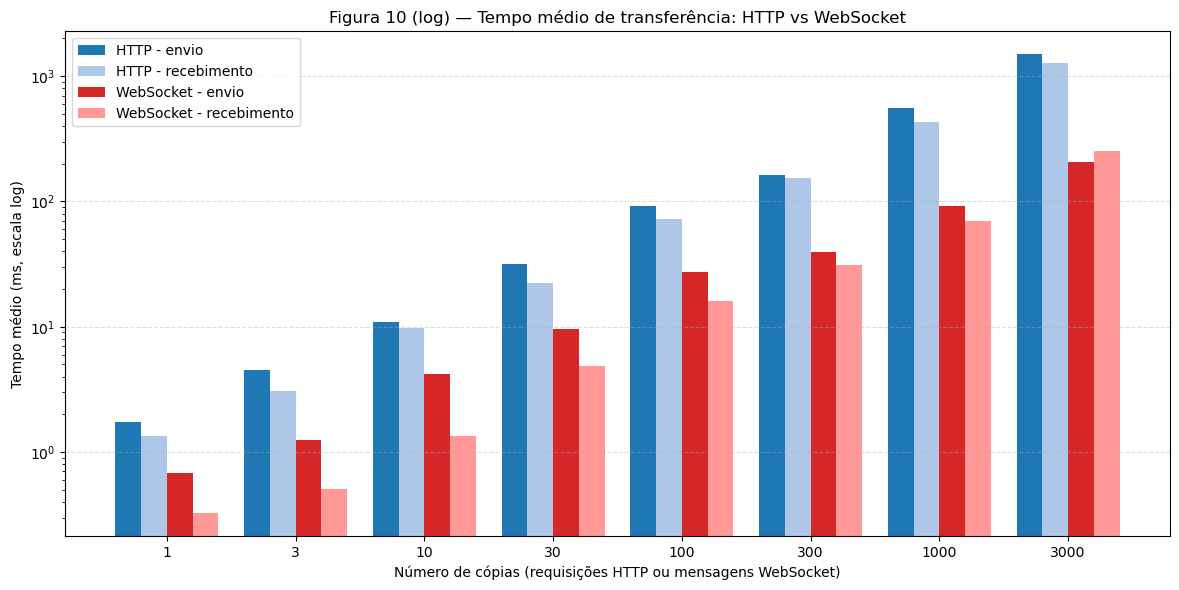

In [22]:
fig, ax = plot_grouped_bars(
    means,
    "Figura 10 (log) — Tempo médio de transferência: HTTP vs WebSocket",
)
ax.set_yscale("log")
ax.set_ylabel("Tempo médio (ms, escala log)")
plt.show()

## Ganho percentual do WebSocket em relação ao HTTP

Replica a conclusão central do artigo (seções 4.4 e 5): a partir de qual quantidade de cópias o WebSocket passa a ser significativamente mais rápido que o HTTP, e de quanto é esse ganho.

In [23]:
gain = pd.DataFrame({
    "HTTP envio (ms)": means["HTTP - envio"],
    "WS envio (ms)": means["WebSocket - envio"],
    "Ganho envio (%)": (means["HTTP - envio"] - means["WebSocket - envio"]) / means["HTTP - envio"] * 100,
    "HTTP recebimento (ms)": means["HTTP - recebimento"],
    "WS recebimento (ms)": means["WebSocket - recebimento"],
    "Ganho recebimento (%)": (means["HTTP - recebimento"] - means["WebSocket - recebimento"]) / means["HTTP - recebimento"] * 100,
})
gain.round(1)

,HTTP envio (ms),WS envio (ms),Ganho envio (%),HTTP recebimento (ms),WS recebimento (ms),Ganho recebimento (%)
copies,,,,,,
1,1.7,0.7,61.0,1.3,0.3,75.7
3,4.5,1.3,72.4,3.1,0.5,83.5
10,10.8,4.2,61.2,9.7,1.3,86.3
30,31.9,9.6,69.7,22.5,4.9,78.2
100,91.4,27.4,70.0,71.8,16.0,77.7
300,161.7,39.7,75.4,153.3,31.0,79.8
1000,559.3,91.4,83.7,430.0,70.3,83.6
3000,1494.3,205.9,86.2,1279.2,254.7,80.1


## Exportando as figuras

Salva os gráficos (linear e log) como PNG em `results/notebook/plots/`, prontos para o relatório.

Figuras salvas em: /home/ryan-correia/Área de trabalho/.projetos/repositorios/github/ComputerNetworksManagement/ifpb/converged_networks/advanced_project/data/plots


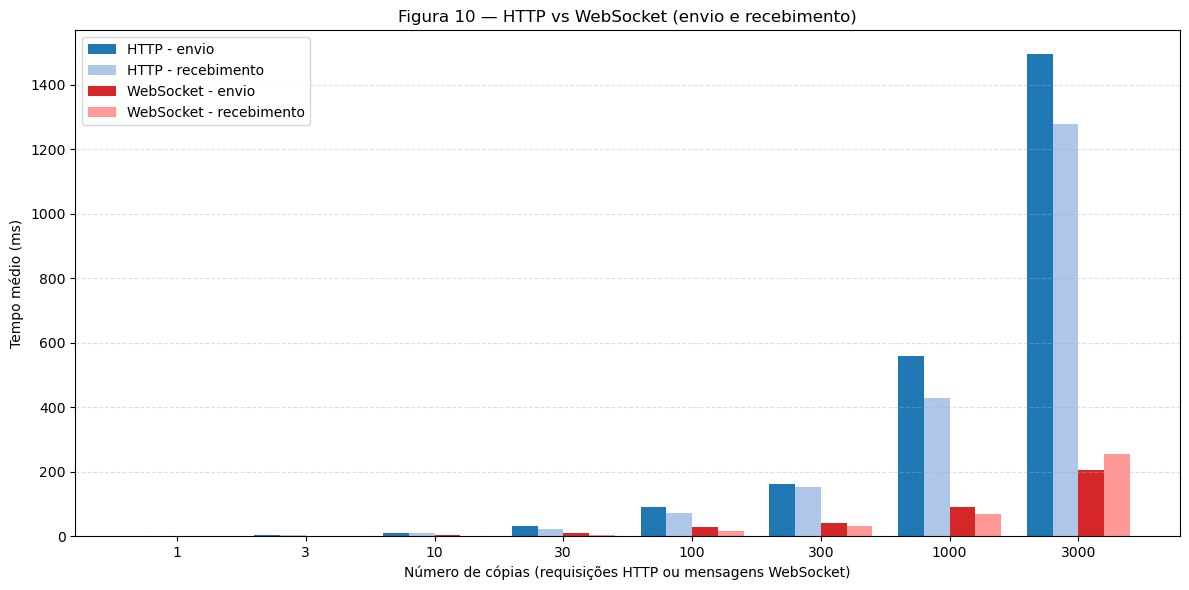

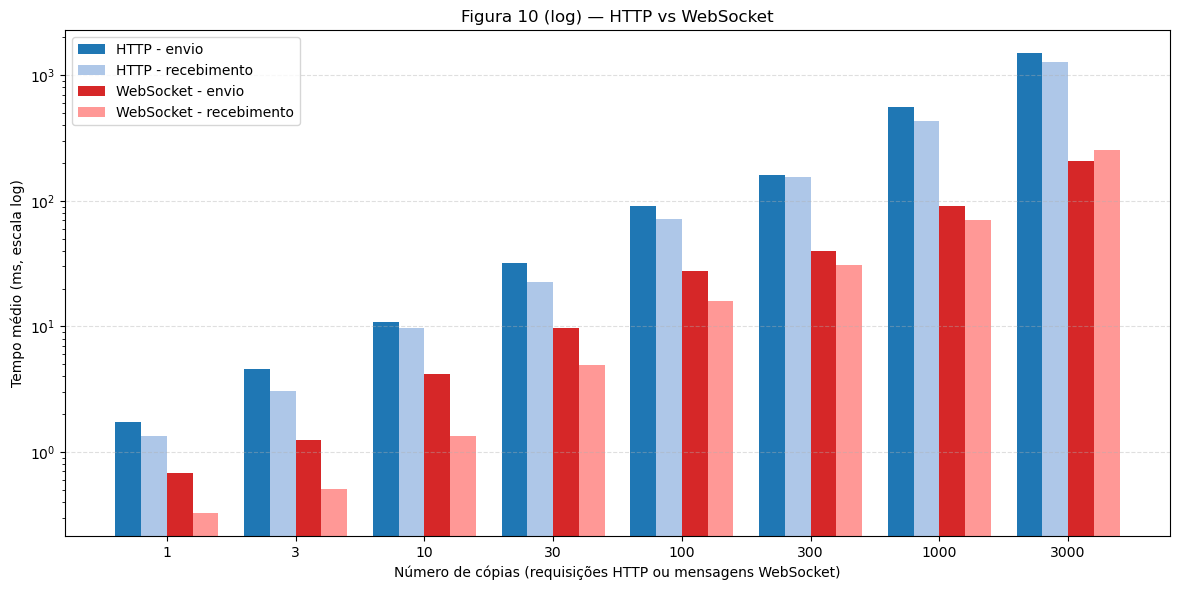

In [24]:
OUT_DIR = Path.cwd().parents[0] / "plots"
OUT_DIR.mkdir(exist_ok=True)

fig_linear, _ = plot_grouped_bars(means, "Figura 10 — HTTP vs WebSocket (envio e recebimento)")
fig_linear.savefig(OUT_DIR / "figura10_http_vs_ws.png", dpi=150)

fig_log, ax_log = plot_grouped_bars(means, "Figura 10 (log) — HTTP vs WebSocket")
ax_log.set_yscale("log")
ax_log.set_ylabel("Tempo médio (ms, escala log)")
fig_log.savefig(OUT_DIR / "figura10_http_vs_ws_log.png", dpi=150)

print(f"Figuras salvas em: {OUT_DIR.resolve()}")